All the following is based on the best model before reweighting the cost functions:

SHAP:

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier  # assuming best model is XGBoost

RANDOM_SEED = 42

# 1. LOAD + MERGE DATA
# =========================
X = pd.read_csv("all_x.csv")
y = pd.read_csv("all_y.csv")

df = X.merge(y, on='building_id')


# 2. PREPROCESS 

X = df.drop(['building_id', 'damage_grade'], axis=1)
y = df['damage_grade'] - 1

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

# =========================
# 3. BUILD BEST MODEL (use your best params)
# =========================
best_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])


# 4. TRAIN FINAL MODEL
pipe.fit(X_train, y_train)


# 5. PREP FOR SHAP (scaling)
scaler = pipe.named_steps["scaler"]
fitted_model = pipe.named_steps["model"]





C:\Users\Freya DING\AppData\Local\Temp\ipykernel_27672\421847089.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [ ]:


df_importance = df_importance.sort_values(by="level1_effect", key=lambda x:np.abs(x), ascending=False)

print(df_importance.head(20))


                                   feature  level1_effect  level2_effect  \
0                           geo_level_1_id      -0.411038      -0.004508   
8      has_superstructure_mud_mortar_stone      -0.186781      -0.000358   
4                                      age      -0.176359      -0.000173   
1                           geo_level_2_id      -0.075882       0.003988   
35                       foundation_type_r      -0.071404      -0.000112   
3                      count_floors_pre_eq      -0.052230       0.006987   
47                      other_floor_type_q      -0.031100      -0.000778   
7             has_superstructure_adobe_mud      -0.029171       0.000758   
9            has_superstructure_stone_flag      -0.021501      -0.000343   
40                             roof_type_x      -0.020048      -0.000123   
6                        height_percentage      -0.019388      -0.009817   
18                          count_families      -0.017719       0.000084   
48          

In [39]:
top_features = df_importance.head(20)["feature"].tolist()  # prepared for GAM

GAM:  

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from pygam import LogisticGAM, s, f
import matplotlib.pyplot as plt


X = pd.read_csv("all_x.csv")
y = pd.read_csv("all_y.csv")
df = X.merge(y, on="building_id")

X = df.drop(["building_id", "damage_grade"], axis=1)
y = df["damage_grade"] - 1   # change the namely level 1,2,3 into 0,1,2


# training-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# drop has_secondary_use to avoid double counting
X_train_clean = X_train.drop(columns=["has_secondary_use"], errors="ignore")
X_test_clean  = X_test.drop(columns=["has_secondary_use"], errors="ignore")



In [20]:
from pygam import s
from pygam import l

y_train_2 = (y_train >= 1).astype(int)
y_train_3 = (y_train >= 2).astype(int)

# one-hot
X_gam = pd.get_dummies(X_train_clean, drop_first=False)



# to construct GAM terms:
def is_onehot(col):
    return set(col.unique()) <= {0,1}

term_list=[]
for i in range(X_gam.shape[1]):
    col=X_gam.iloc[:,i]
    if is_onehot(col):
        term_list.append(l(i))
    else:
        term_list.append(s(i))

terms=term_list[0]
for t in term_list[1:]:
    terms=terms+t


# to train the model

gam_2 = LogisticGAM(terms).fit(X_gam.values, y_train_2.values)
gam_3 = LogisticGAM(terms).fit(X_gam.values, y_train_3.values)


In [21]:
# saved just in case
X_sample = X_gam.sample(n=100000, random_state=42)     # to save computation
y2_sample=y_train_2.loc[X_sample.index]
y3_sample=y_train_3.loc[X_sample.index]

In [ ]:

top_idx = [X_sample.columns.get_loc(f) for f in top_features]

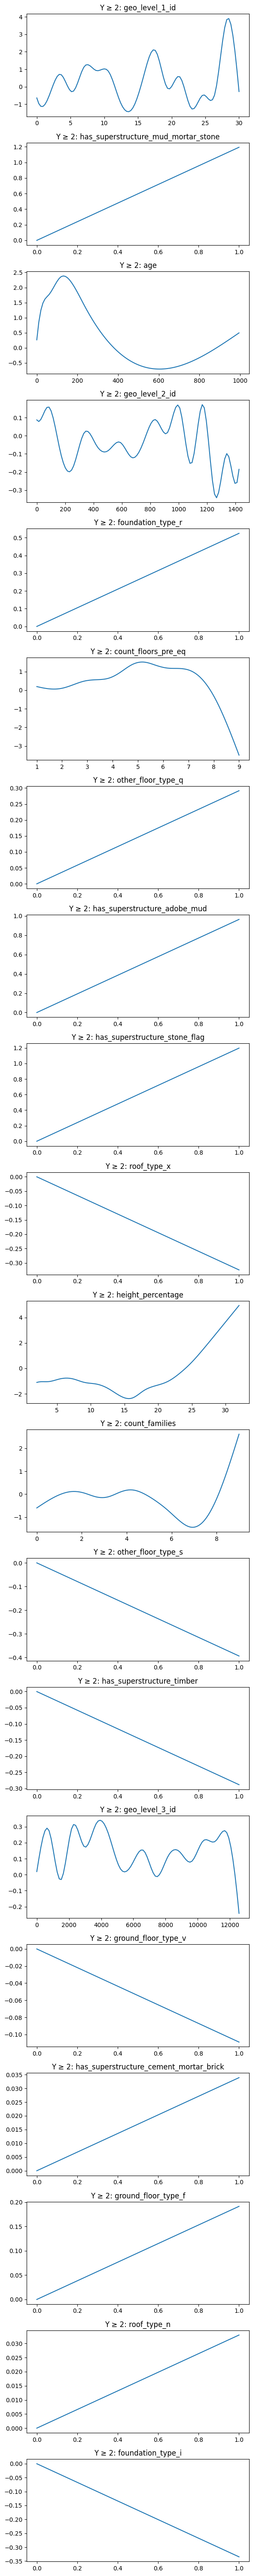

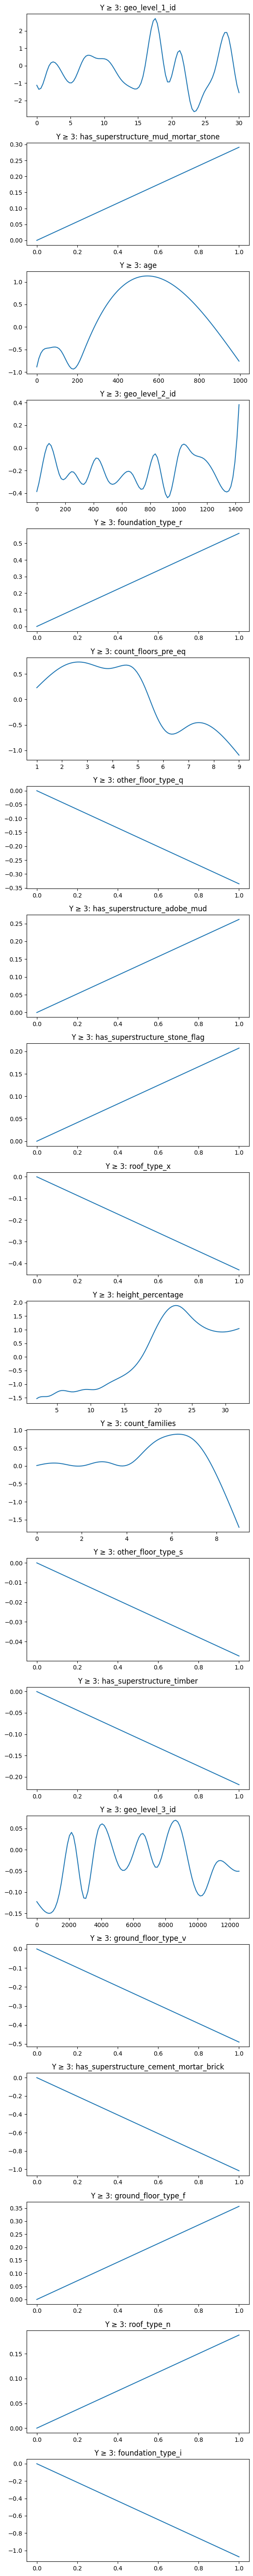

In [41]:
import matplotlib.pyplot as plt

def plot_gam_top(gam, X, idx_list, title):
    fig, axs = plt.subplots(len(idx_list), 1, figsize=(6, 3*len(idx_list)))

    if len(idx_list) == 1:
        axs = [axs]

    for k, i in enumerate(idx_list):
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i, X=XX)

        axs[k].plot(XX[:, i], pdep)
        axs[k].set_title(f"{title}: {X.columns[i]}")

    plt.tight_layout()
    plt.show()
    
plot_gam_top(gam_2, X_sample, top_idx, "Y ≥ 2")
plot_gam_top(gam_3, X_sample, top_idx, "Y ≥ 3")

interpretation of values on y-axis: relative effect on log-odds: <0: decrease the corresponding porb, >0: increase the prob

To save computation, we use s(i)